# Utilisation des dispositifs Bitalino

In [1]:
import sys
sys.path

['',
 'c:\\python\\python35.zip',
 'c:\\python\\DLLs',
 'c:\\python\\lib',
 'c:\\python',
 'C:\\Users\\Francois\\AppData\\Roaming\\Python\\Python35\\site-packages',
 'c:\\python\\lib\\site-packages',
 'c:\\python\\lib\\site-packages\\statsmodels-0.8.0-py3.5-win32.egg',
 'c:\\python\\lib\\site-packages\\IPython\\extensions',
 'C:\\Users\\Francois\\.ipython']

## Connexion

In [9]:
import time
import numpy as np
import matplotlib.pyplot as plt

from bitalino import BITalino
import bitalino as bt

# The macAddress variable on Windows can be "XX:XX:XX:XX:XX:XX" or "COMX"
# while on Mac OS can be "/dev/tty.BITalino-XX-XX-DevB" 
# for devices ending with the last 4 digits of the MAC address 
# or "/dev/tty.BITalino-DevB" for the remaining
devices = {
    "HeartBIT1": "20:17:09:18:59:61", # Red
    "HeartBIT2": "20:19:07:00:80:B3",
    "NeuroBIT1": "20:18:08:08:01:88", # Blue
    "NeuroBIT2": "00:21:06:BE:16:15",
    "MuscleBIT1": "20:18:08:08:02:30", # Green
    "MuscleBIT2": "20:19:07:00:7F:7A",
    "PsychoBIT1": "20:18:05:28:47:03", # White
    "PsychoBIT2": "00:21:06:BE:15:4F"
}

# This example will collect data for 10 sec.
running_time = 10
    
batteryThreshold = 30
acqChannels = [0, 1, 2, 3, 4, 5]
samplingRate = 1000
nSamples = 10
digitalOutput = [1,1]

In [13]:
# Retrieve the MAC addresses and devices names
bt.find()

[('20:18:05:28:47:03', 'BITalino-47-03'),
 ('20:18:08:08:01:88', 'BITalino-01-88'),
 ('20:18:08:08:02:30', 'BITalino-02-30'),
 ('20:19:07:00:80:B3', 'BITalino-80-B3'),
 ('20:17:09:18:59:61', 'BITalino-59-61')]

In [11]:
# Choose a device
macAddress = devices["HeartBIT2"]

## Acquisition de données

In [12]:
# Connect to BITalino
device = BITalino(macAddress)

In [14]:
# Set battery threshold
device.battery(batteryThreshold)

# Read BITalino version
print(device.version())
    
# Start Acquisition
device.start(samplingRate, acqChannels)

data = []
start = time.time()
end = time.time()
while (end - start) < running_time:
    # Read samples
    dataRead = device.read(nSamples)
    data.append(dataRead)
    print(dataRead)
    end = time.time()

# Turn BITalino led on
device.trigger(digitalOutput)
    
# Stop acquisition
device.stop()
    
# Close connection
device.close()

BITalino_v5.2
[[ 0.  1.  1.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 1.  1.  1.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 2.  1.  1.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 3.  1.  1.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 4.  1.  1.  0.  0.  2.  0.  0.  0.  0.  0.]
 [ 5.  1.  1.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 6.  1.  1.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 7.  1.  1.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 8.  1.  1.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 9.  1.  1.  0.  0.  0.  0.  0.  0.  0.  0.]]
[[ 10.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [ 11.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [ 12.   1.   1.   0.   0.   2.   0.   0.   0.   0.   0.]
 [ 13.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [ 14.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [ 15.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  0.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  1.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  2.   1.   1.   0.   0.   0.   0.   0.   0.   0.

[[ 0.  1.  1.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 1.  1.  1.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 2.  1.  1.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 3.  1.  1.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 4.  1.  1.  0.  0.  2.  0.  0.  0.  0.  0.]
 [ 5.  1.  1.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 6.  1.  1.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 7.  1.  1.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 8.  1.  1.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 9.  1.  1.  0.  0.  0.  0.  0.  0.  0.  0.]]
[[ 10.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [ 11.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [ 12.   1.   1.   0.   0.   2.   0.   0.   0.   0.   0.]
 [ 13.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [ 14.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [ 15.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  0.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  1.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  2.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  3. 

 [ 13.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]]
[[ 14.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [ 15.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  0.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  1.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  2.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  3.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  4.   1.   1.   0.   0.   1.   0.   0.   0.   0.   0.]
 [  5.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  6.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  7.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]]
[[  8.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  9.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [ 10.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [ 11.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [ 12.   1.   1.   0.   0.   1.   0.   0.   0.   0.   0.]
 [ 13.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [ 14.   1. 

[[ 14.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [ 15.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  0.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  1.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  2.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  3.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  4.   1.   1.   0.   0.   2.   0.   0.   0.   0.   0.]
 [  5.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  6.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  7.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]]
[[  8.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  9.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [ 10.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [ 11.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [ 12.   1.   1.   0.   0.   2.   0.   0.   0.   0.   0.]
 [ 13.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [ 14.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [ 15.   1.  

 [  1.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]]
[[  2.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  3.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  4.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  5.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  6.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  7.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  8.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  9.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [ 10.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [ 11.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]]
[[ 12.   1.   1.   0.   0.   2.   0.   0.   0.   0.   0.]
 [ 13.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [ 14.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [ 15.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  0.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  1.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  2.   1. 

...

 [  3.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]]
[[  4.   1.   1.   0.   0.   2.   0.   0.   0.   0.   0.]
 [  5.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  6.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  7.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  8.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  9.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [ 10.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [ 11.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [ 12.   1.   1.   0.   0.   2.   0.   0.   0.   0.   0.]
 [ 13.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]]
[[ 14.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [ 15.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  0.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  1.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  2.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  3.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  4.   1. 

 [  7.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]]
[[  8.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  9.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [ 10.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [ 11.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [ 12.   1.   1.   0.   0.   2.   0.   0.   0.   0.   0.]
 [ 13.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [ 14.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [ 15.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  0.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  1.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]]
[[  2.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  3.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  4.   1.   1.   0.   0.   2.   0.   0.   0.   0.   0.]
 [  5.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  6.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  7.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  8.   1. 

 [ 11.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]]
[[ 12.   1.   1.   0.   0.   2.   0.   0.   0.   0.   0.]
 [ 13.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [ 14.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [ 15.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  0.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  1.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  2.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  3.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  4.   1.   1.   0.   0.   1.   0.   0.   0.   0.   0.]
 [  5.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]]
[[  6.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  7.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  8.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  9.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [ 10.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [ 11.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [ 12.   1. 

 [  3.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]]
[[  4.   1.   1.   0.   0.   2.   0.   0.   0.   0.   0.]
 [  5.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  6.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  7.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  8.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  9.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [ 10.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [ 11.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [ 12.   1.   1.   0.   0.   2.   0.   0.   0.   0.   0.]
 [ 13.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]]
[[ 14.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [ 15.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  0.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  1.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  2.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  3.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  4.   1. 

[[  2.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  3.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  4.   1.   1.   0.   0.   2.   0.   0.   0.   0.   0.]
 [  5.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  6.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  7.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  8.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  9.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [ 10.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [ 11.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]]
[[ 12.   1.   1.   0.   0.   2.   0.   0.   0.   0.   0.]
 [ 13.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [ 14.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [ 15.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  0.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  1.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  2.   1.   1.   0.   0.   0.   0.   0.   0.   0.   0.]
 [  3.   1.  

## Affichage de données brutes

In [11]:
def showData(data, channel):
    dictChannels = {"A1":5, "A2":6, "A3":7, "A4":8, "A5":9, "A6":10}
    channelCode = dictChannels[channel]
    L = []
    for d in data:
        for dd in d:
            L.append(dd[channelCode])
            #print(dd[6]) # 6 = A2
    plt.plot(L)
    plt.show()
    return L

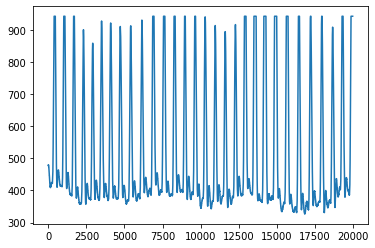

In [12]:
showData(data, "A1");

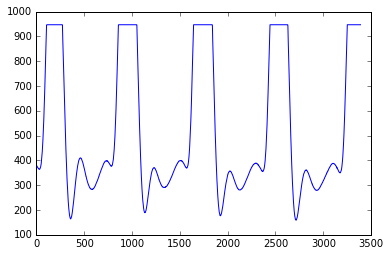

In [51]:
showData(data, "A1");

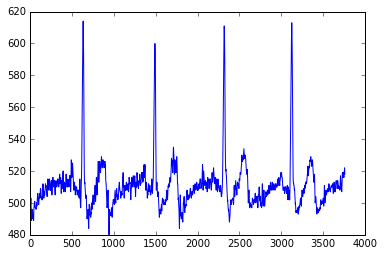

In [42]:
showData(data, "A2");

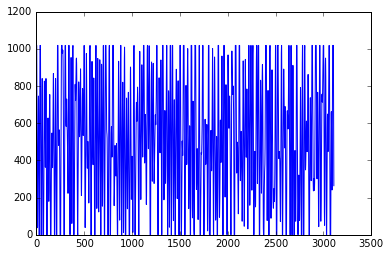

In [56]:
showData(data, "A2");

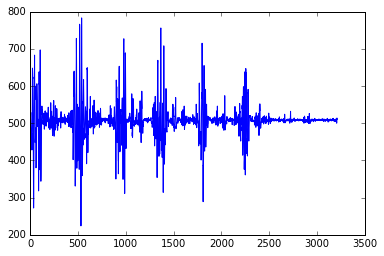

In [64]:
showData(data, "A2");

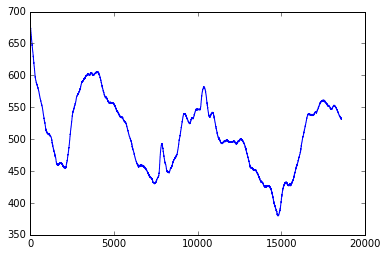

In [75]:
showData(data, "A2");

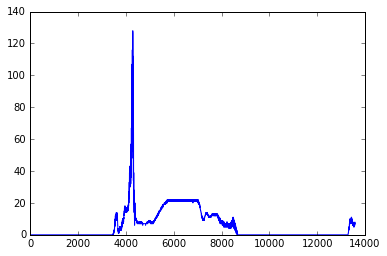

In [85]:
showData(data, "A4");

## Lecture depuis un fichier texte et affichage

In [102]:
filename = "C:\\Users\\Francois\\Documents\\OpenSignals (r)evolution\\files\\opensignals_psychobit white_2019-11-14_13-06-13.txt"

In [92]:
from numpy import loadtxt # package de lecture
import biosignalsnotebooks as bsnb 

data = loadtxt(filename)
data

array([[ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [ 1.,  0.,  0., ...,  0.,  0.,  0.],
       [ 2.,  0.,  0., ...,  0.,  0.,  0.],
       ..., 
       [ 4.,  0.,  0., ...,  0.,  0.,  0.],
       [ 5.,  0.,  0., ...,  0.,  0.,  0.],
       [ 6.,  0.,  0., ...,  0.,  0.,  0.]])

In [98]:
sampling_rate = 100
time = bsnb.generate_time(data, sampling_rate) # génère l'axe de temps au sampling choisi
channel_column = 6
bsnb.plot(time, data[:, channel_column])

### Lecture de l'entête d'un fichier

In [101]:
import biosignalsnotebooks as bsnb # biosignalsnotebooks Python package with useful functions
from ast import literal_eval # Package to process Python abstract syntax grammar Abstract (Abstract Syntax Trees)

In [108]:
# Open file
file_txt = open(filename, "r")

# The "readlines" method returns a list where each entry contains a line of the .txt file
txt_data = file_txt.readlines()

# We only need the content of line 2 (entry 1 of "txt_data" list)
metadata = txt_data[1]

# Close file
file_txt.close()

In [109]:
metadata

'# {"20:18:05:28:47:03": {"sensor": ["RESPBIT", "RESPBIT", "RAW", "RAW", "RAW", "RAW"], "device name": "PsychoBIT White", "column": ["nSeq", "I1", "I2", "O1", "O2", "A1", "A2", "A3", "A4", "A5", "A6"], "sync interval": 2, "time": "13:6:15.948", "comments": "Test respi", "device connection": "BTH20:18:05:28:47:03", "channels": [1, 2, 3, 4, 5, 6], "keywords": "", "mode": 0, "digital IO": [0, 0, 1, 1], "firmware version": 1281, "device": "bitalino_rev", "position": 0, "sampling rate": 100, "label": ["A1", "A2", "A3", "A4", "A5", "A6"], "resolution": [4, 1, 1, 1, 1, 10, 10, 10, 10, 6, 6], "date": "2019-11-14", "special": [{}, {}, {}, {}, {}, {}]}}\n'

In [110]:
# suppression des caractères de début et de fin
metadata_aux = metadata[2:-1]

# conversion en dictionnaire
header_txt = literal_eval(metadata_aux)

In [111]:
header_txt

{'20:18:05:28:47:03': {'channels': [1, 2, 3, 4, 5, 6],
  'column': ['nSeq',
   'I1',
   'I2',
   'O1',
   'O2',
   'A1',
   'A2',
   'A3',
   'A4',
   'A5',
   'A6'],
  'comments': 'Test respi',
  'date': '2019-11-14',
  'device': 'bitalino_rev',
  'device connection': 'BTH20:18:05:28:47:03',
  'device name': 'PsychoBIT White',
  'digital IO': [0, 0, 1, 1],
  'firmware version': 1281,
  'keywords': '',
  'label': ['A1', 'A2', 'A3', 'A4', 'A5', 'A6'],
  'mode': 0,
  'position': 0,
  'resolution': [4, 1, 1, 1, 1, 10, 10, 10, 10, 6, 6],
  'sampling rate': 100,
  'sensor': ['RESPBIT', 'RESPBIT', 'RAW', 'RAW', 'RAW', 'RAW'],
  'special': [{}, {}, {}, {}, {}, {}],
  'sync interval': 2,
  'time': '13:6:15.948'}}

Extraction de la fréquence d'échantillonnage :

In [114]:
header_txt["20:18:05:28:47:03"]["sampling rate"]

100

# Debug

In [7]:
from bluetooth import *
devices = discover_devices()
for device in devices:
    print([_ for _ in find_service(address=device) if 'RFCOMM' in _['protocol'] ])
# now manually select the desired device or hardcode its name/mac whatever in the script
bt_addr = "20:17:09:18:59:61"
port = [_ for _ in find_service(address=bt_addr) if 'RFCOMM' in _['protocol']][0]['port']
s = BluetoothSocket(RFCOMM)
s.connect((bt_addr, port))

[]


IndexError: list index out of range